In [144]:
import pandas as pd

bars_df = pd.read_parquet("../data/bars_seen_train.parquet")
unseen_bars_df = pd.read_parquet("../data/bars_unseen_train.parquet")
sentiment_df = pd.read_csv("../sentiment_overview.csv")
headlines_df_seen = pd.read_parquet("../data/headlines_seen_train.parquet")
headlines_df_unseen = pd.read_parquet("../data/headlines_unseen_train.parquet")

print(sentiment_df.head())
print(bars_df.head())

   session                headline  bar_ix decided_label  prob_positive  \
0        0      Relvos Biosciences       6       neutral       0.387032   
1        0       Orevex Renewables      12      positive       0.948091   
2        0      Relvos Biosciences      14       neutral       0.061307   
3        0         Calvis Sciences      20      positive       0.945060   
4        0  Yorvov Pharmaceuticals      22      positive       0.947761   

   prob_negative  prob_neutral  linear_score  polarity_score  cluster  
0       0.013454      0.599514      0.373578        0.932811        0  
1       0.012295      0.039614      0.935795        0.974395        1  
2       0.040272      0.898421      0.021034        0.207074        0  
3       0.010088      0.044852      0.934971        0.978876        0  
4       0.012083      0.040155      0.935678        0.974823        0  
   bar_ix  session  open    high     low   close
0       0        0   1.0  1.0029  0.9986  0.9999
1       0        1 

Nolvol Resources secures $50M contract with a major logistics provider
6
Nolvol Resources wins industry award for excellence in cloud infrastructure
7
Creven Securities names new head of automated logistics division
23
Nolvol Resources secures $320M contract with a multinational manufacturer
25
Nolvol Resources revises long-term strategy with focus on renewable storage
25
Creven Securities faces class action over process automation service disruption
27
Creven Securities completes strategic acquisition to strengthen digital payments
36
Ulvon Renewables announces breakthrough in automated logistics
36
Ulvon Renewables announces $5.7B share buyback program
51
hello
Ulvon Renewables secures $120M contract with a leading cloud platform
56
hello
Kelvik Power announces breakthrough in enterprise software
59
hello
Ulvon Renewables revises long-term strategy with focus on process automation
67
hello
Kelvik Power raises full-year guidance citing robust demand
78
hello
Ulvon Renewables sees 7% m

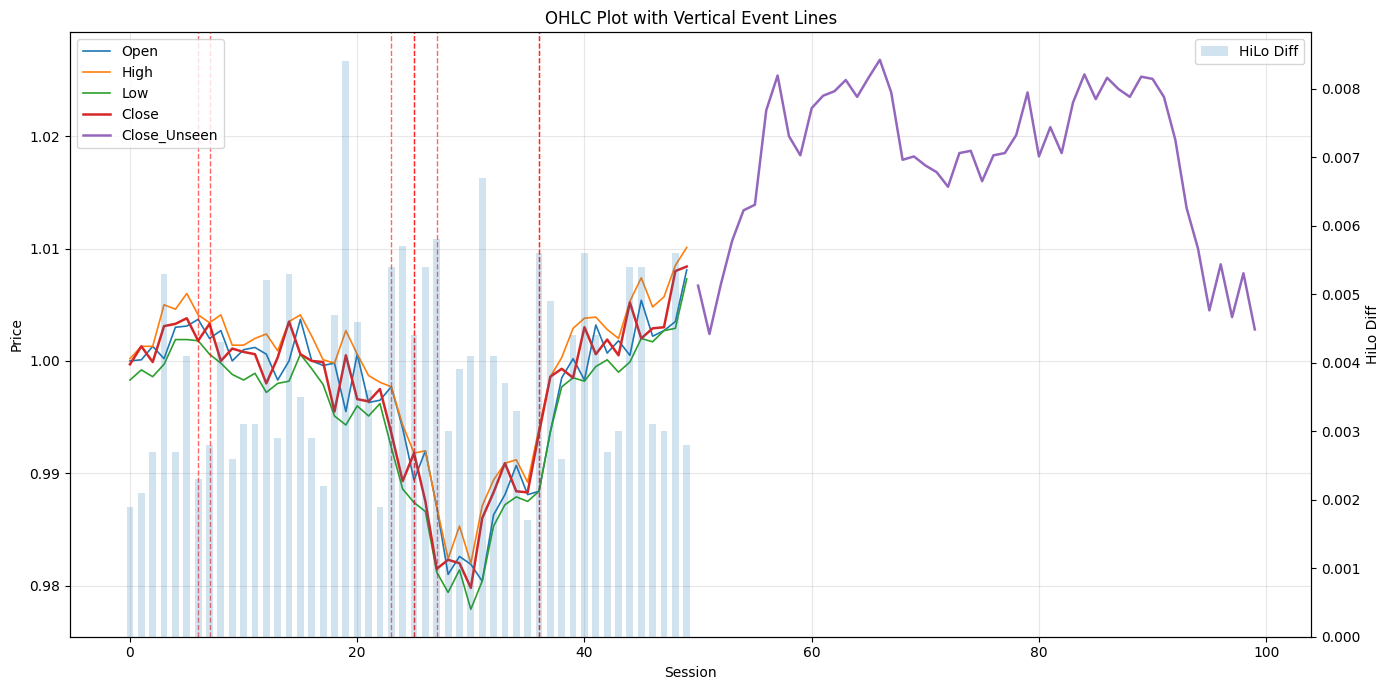

In [151]:
session_of_interest = 67

import pandas as pd
import matplotlib.pyplot as plt

# df  = main dataframe with OHLC data
# df2 = second dataframe containing bar_ix values where vertical lines should be drawn

# Example:
# df2 = pd.DataFrame({"bar_ix": [5, 12, 18, 33, 41]})

df = bars_df[bars_df["session"] == session_of_interest]
df["hilo_diff"] = df["high"] - df["low"]
df2 = sentiment_df[sentiment_df["session"] == session_of_interest]
df_unseen = unseen_bars_df[unseen_bars_df["session"] == session_of_interest]
headlines_df_seen = headlines_df_seen[headlines_df_seen["session"] == session_of_interest]
headlines_df_unseen = headlines_df_unseen[headlines_df_unseen["session"] == session_of_interest]
# print(headlines_df_seen)

for idx, row in headlines_df_seen.iterrows():
    print(row.headline)
    print(row.bar_ix)

for idx, row in headlines_df_unseen.iterrows():
    print(row.headline)
    print(row.bar_ix)
    print("hello")
# print(headlines_df_unseen)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Main OHLC lines
ax1.plot(df["bar_ix"], df["open"],  label="Open", linewidth=1.2)
ax1.plot(df["bar_ix"], df["high"],  label="High", linewidth=1.2)
ax1.plot(df["bar_ix"], df["low"],   label="Low", linewidth=1.2)
ax1.plot(df["bar_ix"], df["close"], label="Close", linewidth=1.8)
ax1.plot(df_unseen["bar_ix"], df_unseen["close"], label="Close_Unseen", linewidth=1.8)

# Add vertical lines at bar_ix positions from df2
for x in df2["bar_ix"]:
    ax1.axvline(x=x, linestyle="--", linewidth=1, alpha=0.6, color="red")

# Secondary axis for hilo_diff
ax2 = ax1.twinx()
ax2.bar(df["bar_ix"], df["hilo_diff"], alpha=0.2, width=0.6, label="HiLo Diff")

# Labels
ax1.set_xlabel("Session")
ax1.set_ylabel("Price")
ax2.set_ylabel("HiLo Diff")

# Title
plt.title("OHLC Plot with Vertical Event Lines")

# Legend
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Grid
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [146]:
def do_single_session(session_of_interest=2):
    df = bars_df[bars_df["session"] == session_of_interest].copy()

    df["hilo_diff"] = df["high"] - df["low"]

    df2 = sentiment_df[sentiment_df["session"] == session_of_interest].copy()

    result = pd.merge(df, df2, on="bar_ix", how="inner")

    only_volatility = result[["bar_ix","headline", "hilo_diff", "prob_positive", "prob_negative", "prob_neutral"]].sort_values(
        by="bar_ix",
        ascending=False   # highest first
    )

    print(only_volatility)

    # candidate_a = only_volatility[only_volatility["headline"] == "Zrovex Industries"]
    # candidate_b = only_volatility[only_volatility["headline"] == "Jorvis Fuels"]
    return (0, 0)
    return candidate_a, candidate_b

In [147]:
a, b = do_single_session(session_of_interest=session_of_interest)

   bar_ix           headline  hilo_diff  prob_positive  prob_negative  \
6      36  Creven Securities     0.0056       0.905404       0.009806   
7      36   Ulvon Renewables     0.0056       0.697543       0.012752   
5      27  Creven Securities     0.0058       0.011160       0.929367   
3      25   Nolvol Resources     0.0044       0.926515       0.009328   
4      25   Nolvol Resources     0.0044       0.260650       0.008594   
2      23  Creven Securities     0.0054       0.056675       0.037038   
1       7   Nolvol Resources     0.0028       0.923432       0.011317   
0       6   Nolvol Resources     0.0023       0.949159       0.013399   

   prob_neutral  
6      0.084791  
7      0.289705  
5      0.059473  
3      0.064157  
4      0.730755  
2      0.906287  
1      0.065251  
0      0.037442  


In [148]:
a

0

In [149]:
b

0

In [ ]:
def do_single_session(session_of_interest=2):
    news_df = sentiment_df[sentiment_df["session"] == session_of_interest].copy()
    news_df = news_df.copy()
    news_df["company"] = news_df["headline"]

    # ---------------------------------------------------------
    # STEP 2: Convert sentiment probabilities into one score
    # positive = +1
    # negative = -1
    # neutral = 0
    # ---------------------------------------------------------
    news_df["sentiment_score"] = (
        news_df["prob_positive"] - news_df["prob_negative"]
    )

    # ---------------------------------------------------------
    # STEP 3: Aggregate sentiment by bar_ix and company
    # ---------------------------------------------------------
    sentiment = (
        news_df.groupby(["company", "bar_ix"], as_index=False)
        .agg(sentiment_score=("sentiment_score", "mean"))
    )

    # ---------------------------------------------------------
    # STEP 4: Create price movement metric
    # Use close-open return for each session
    # Then average over sessions for same bar_ix
    # ---------------------------------------------------------
    price_df = bars_df[bars_df["session"] == session_of_interest].copy()
    price_df = price_df.copy()

    price_df["ret"] = (price_df["close"] - price_df["open"]) / price_df["open"]

    price_move = (
        price_df.groupby("bar_ix", as_index=False)
        .agg(price_return=("ret", "mean"))
    )

    # ---------------------------------------------------------
    # STEP 5: Merge each company sentiment with unknown price
    # ---------------------------------------------------------
    merged = sentiment.merge(price_move, on="bar_ix", how="inner")

    # ---------------------------------------------------------
    # STEP 6: Score each company
    # Compare sentiment vs price direction
    # correlation + directional hit rate
    # ---------------------------------------------------------
    results = []

    for company, g in merged.groupby("company"):
        
        if len(g) < 2:
            continue
        
        # Correlation
        corr = g["sentiment_score"].corr(g["price_return"])
        
        # Direction match
        sent_sign = np.sign(g["sentiment_score"])
        px_sign   = np.sign(g["price_return"])
        
        hitrate = (sent_sign == px_sign).mean()
        
        # Combined score
        score = 0.7 * corr + 0.3 * hitrate
        
        results.append({
            "company": company,
            "n_bars": len(g),
            "corr": corr,
            "hitrate": hitrate,
            "score": score
        })

    results_df = pd.DataFrame(results).sort_values("score", ascending=False)

    print(results_df)